# Clustering jerárquico

**Datos de ejemplo.** Calificaciones de estudiantes (`data/Estudiantes.xlsx`): cada fila es un alumno; la columna **Nombre** identifica la observación y el resto son asignaturas numéricas.

**Contenido del notebook**

1. Carga y revisión rápida de los datos  
2. Indicios de *clusterabilidad* (Hopkins y mapas de distancias / VAT)  
3. Estandarización de variables  
4. Dendrogramas con distintos **enlaces** (single, complete, average, Ward)  
5. Elección de **k** con silueta y apoyo de la **correlación cophenética**  
6. Interpretación: perfiles en barras, radar, mapa de calor, **PCA** y diagrama de **silueta** por observación  
7. Tabla resumen con la asignación de cluster  

**Gráficos.** Las figuras están en `scripts/graficos_interpretacion.py` (importadas como `gr`).


## 1. Librerías

Usamos **NumPy** y **pandas** para datos; **SciPy** para distancias, enlaces y dendrogramas; **scikit-learn** para estandarizar, PCA, clustering aglomerativo y métricas de silueta; **Matplotlib** y **Seaborn** para figuras con estilo consistente.


In [1]:

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import cophenet, fcluster, leaves_list, linkage
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

SCRIPTS = Path.cwd() / "scripts"
sys.path.insert(0, str(SCRIPTS.resolve()))
import graficos_interpretacion as gr

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
%matplotlib inline


## 2. Funciones auxiliares


In [2]:

def hopkins_statistic(X: np.ndarray, m: int | None = None, *, seed: int = 42) -> float:
    rng = np.random.default_rng(seed)
    n, d = X.shape
    if n < 3:
        raise ValueError("Se necesitan al menos 3 filas.")
    m = max(2, min(int(m or max(2, min(n - 1, n // 2))), n - 1))
    lo, hi = X.min(axis=0), X.max(axis=0)
    u = np.empty(m)
    for i in range(m):
        j = int(rng.integers(0, n))
        dists = np.linalg.norm(X - X[j], axis=1)
        dists[j] = np.inf
        u[i] = dists.min()
    art = rng.uniform(lo, hi, size=(m, d))
    w = cdist(art, X).min(axis=1)
    den = u.sum() + w.sum() + 1e-12
    return float(w.sum() / den)


def vat_order(X: np.ndarray, metric: str = "euclidean") -> tuple[np.ndarray, np.ndarray]:
    # VAT: orden por hoja de enlace single sobre la matriz de distancias.
    met = "cityblock" if metric == "manhattan" else metric
    condensed = pdist(X, metric=met)
    D = squareform(condensed)
    order = np.asarray(leaves_list(linkage(condensed, method="single")), dtype=int)
    return order, D[np.ix_(order, order)]


def centroide(k: int, X_df: pd.DataFrame, labels: np.ndarray) -> pd.Series:
    return X_df.loc[labels == k].mean()


def linkage_euclidean(Z_data: np.ndarray, method: str) -> np.ndarray:
    # Ward sobre observaciones; otros enlaces sobre distancias euclídeas condensadas.
    if method == "ward":
        return linkage(Z_data, method="ward", metric="euclidean")
    return linkage(pdist(Z_data, metric="euclidean"), method=method)


def cophenetic_corr(Z: np.ndarray, X: np.ndarray) -> float:
    return float(cophenet(Z, pdist(X, metric="euclidean"))[0])


## 3. Carga de datos

Lectura desde Excel (`data/Estudiantes.xlsx`). Se usa la columna **Nombre** como identificador de fila; las variables de clustering son todas las columnas **numéricas** (asignaturas).


In [3]:

DATA = Path("data") / "Estudiantes.xlsx"

raw = pd.read_excel(DATA)
id_col = "Nombre"

if id_col not in raw.columns:
    id_col = raw.columns[0]

df = raw.set_index(id_col)

df.index = df.index.astype(str).str.strip()

feature_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
X_raw = df[feature_cols].apply(pd.to_numeric, errors="coerce").astype(float)

df = df.loc[X_raw.dropna(how="any").index]

X_raw = X_raw.dropna(how="any").values

names = df.index.tolist()

print(f"Archivo: {DATA.resolve()}")
print(f"Observaciones: {len(df)} | Variables: {len(feature_cols)}")
display(df[feature_cols].head())


Archivo: /Users/rachitvargaslopez/Documents/LEAD University/Mineria de datos/data_science/data_mining/7 - clustering_jerarquico/data/Estudiantes.xlsx
Observaciones: 10 | Variables: 5


,Matematica,Ciencias,Español,Historia,Educacion F
Nombre,,,,,
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3


## 4. ¿Tiene sentido buscar grupos?

**Hopkins.** Comparación entre distancias de puntos reales a sus vecinos y distancias de puntos sintéticos uniformes. Valores **más altos** indican más estructura que el azar (no hay umbral universal: se usa como apoyo).

**Matriz de distancias y VAT.** El mapa ordenado (VAT) ayuda a ver bloques homogéneos si existen.


Hopkins (aprox.): 0.663


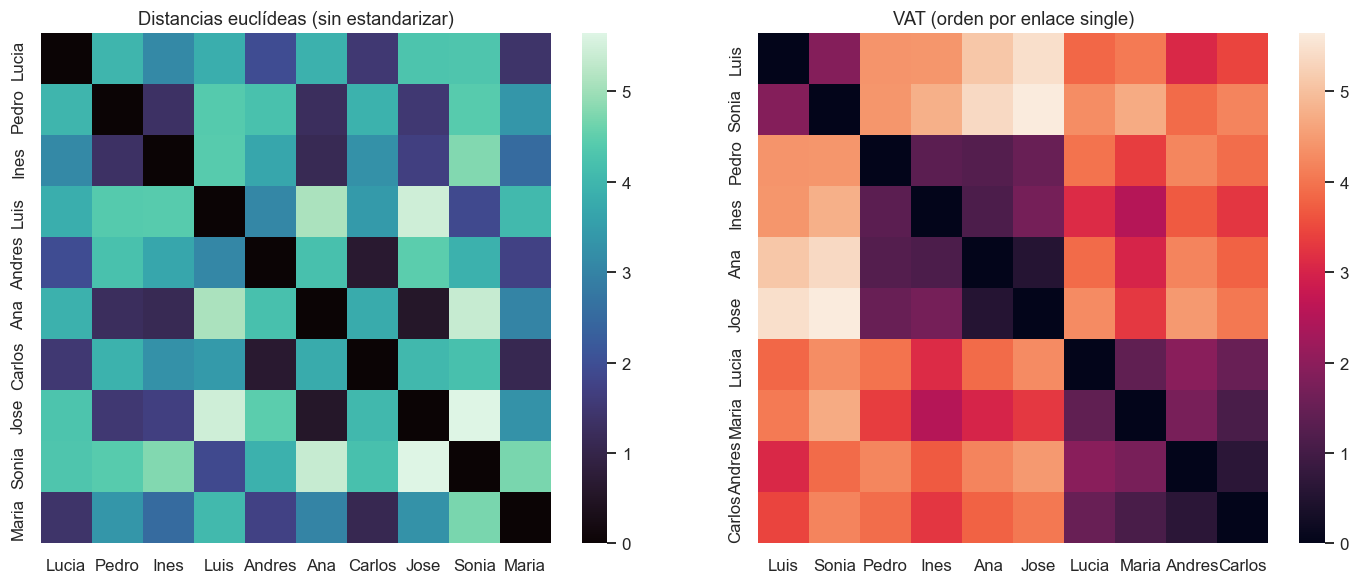

In [4]:
H = hopkins_statistic(X_raw, seed=42)

print(f"Hopkins (aprox.): {H:.3f}")

order, D_ord = vat_order(X_raw, metric="euclidean")
onames = [names[i] for i in order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
gr.plot_matriz_distancias(X_raw, names, axes[0], "Distancias euclídeas (sin estandarizar)")
gr.plot_matriz_vat(D_ord, onames, axes[1], "VAT (orden por enlace single)")

plt.show()



## 5. Estandarización

Las variables están en escalas parecidas, pero **estandarizar** (media 0, varianza 1) evita que ninguna domine solo por su rango y es coherente con **Ward** y la distancia euclídea.


In [5]:

scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols].values)
X_df = pd.DataFrame(X, columns=feature_cols, index=df.index)

print("Media aproximada por columna tras escalar:", X_df.mean().round(3).to_dict())


Media aproximada por columna tras escalar: {'Matematica': -0.0, 'Ciencias': -0.0, 'Español': -0.0, 'Historia': -0.0, 'Educacion F': 0.0}


## 6. Dendrogramas (mismo espacio, distintos enlaces)

- **Single (salto mínimo):** fusiona por el par más cercano; cadenas largas.  
- **Complete (salto máximo):** fusiona por el par más lejano; grupos compactos.  
- **Average:** usa la distancia media entre pares.  
- **Ward:** minimiza varianza intra al fusionar (solo euclídea en la matriz de observaciones).


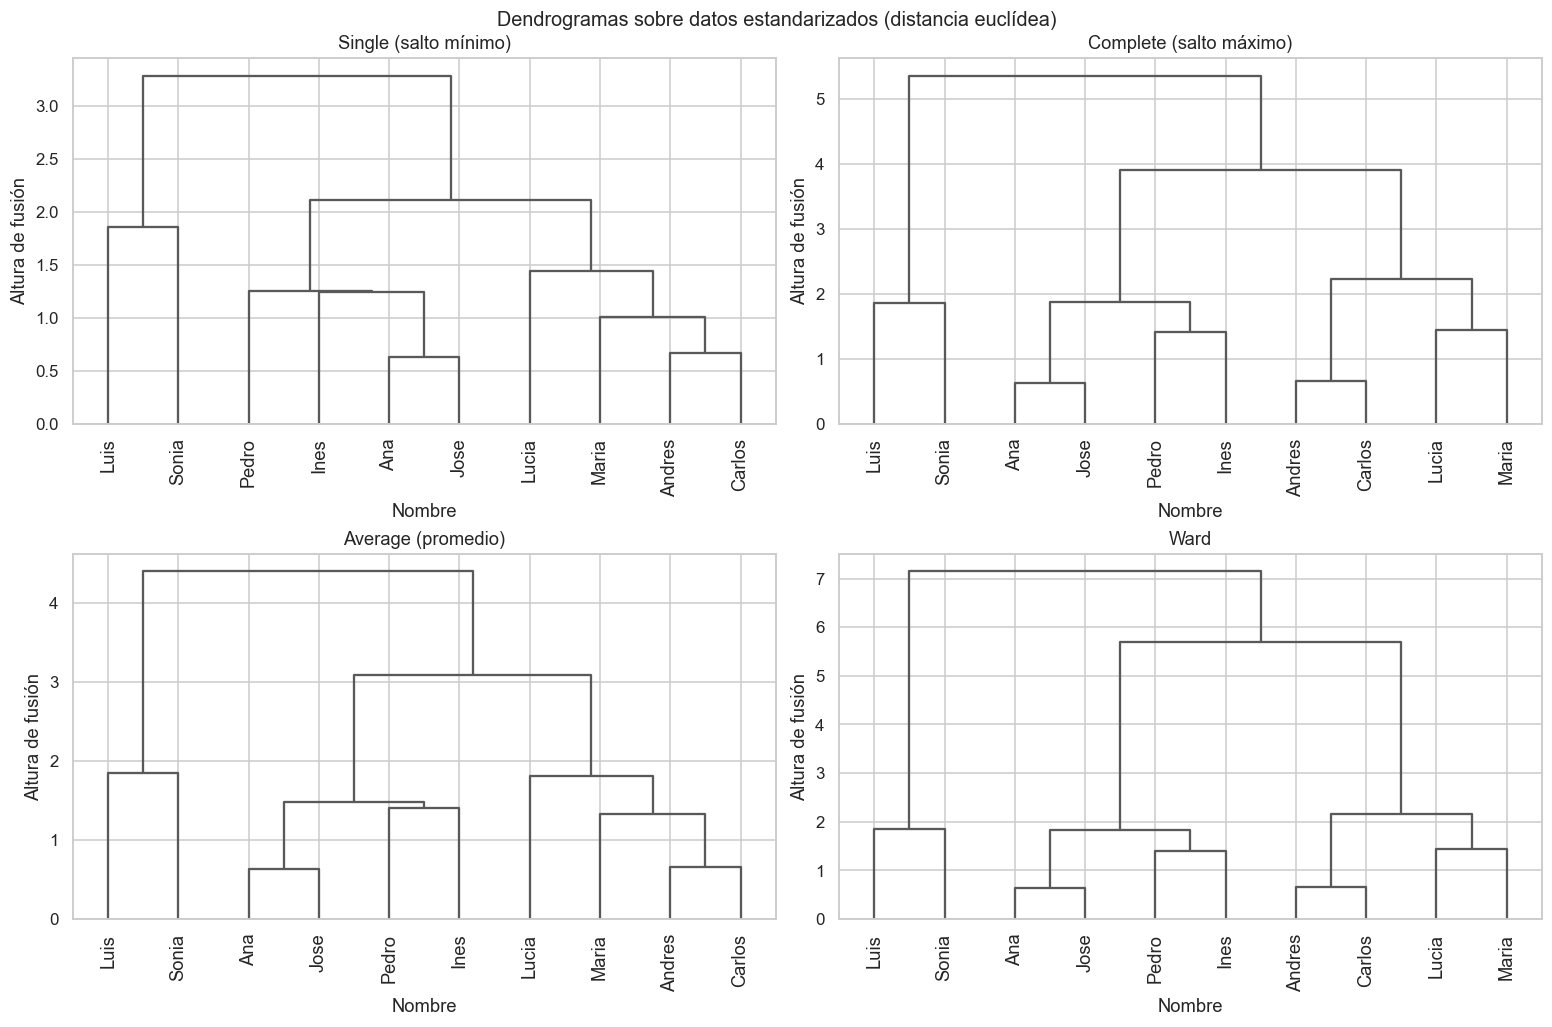

In [6]:
methods = [
    ("single", "Single (salto mínimo)"),
    ("complete", "Complete (salto máximo)"),
    ("average", "Average (promedio)"),
    ("ward", "Ward"),
]

fig = gr.plot_dendrogramas_cuadricula(
    X,
    names,
    methods,
    linkage_euclidean,
    suptitle="Dendrogramas sobre datos estandarizados (distancia euclídea)",
    xlabel="Nombre",
)

plt.show()



## 7. Número de clusters: silueta y cophenética

La **silueta media** compara cohesión dentro del cluster con separación respecto al vecino más cercano. La **correlación cophenética** mide qué tan bien el árbol preserva las distancias originales (valores más altos suelen ser deseables).

Aquí fijamos **k = 3** para la interpretación (puedes cambiar `K` en la siguiente celda).


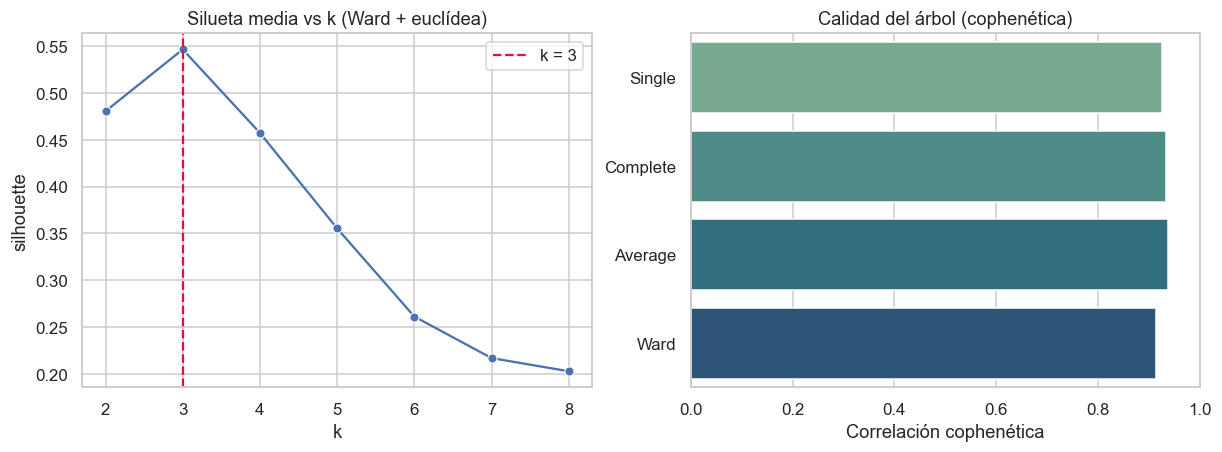

,k,silhouette
0,2,0.4806
1,3,0.5467
2,4,0.4574
3,5,0.3554
4,6,0.2612
5,7,0.2168
6,8,0.2027


In [7]:
K = 3
k_min, k_max = 2, min(8, X.shape[0] - 1)
Z_ward = linkage_euclidean(X, "ward")
rows = []

for k in range(k_min, k_max + 1):
    lab = fcluster(Z_ward, k, criterion="maxclust")
    if len(np.unique(lab)) < 2:
        continue
    rows.append({"k": k, "silhouette": silhouette_score(X, lab, metric="euclidean")})

sil_df = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
gr.plot_silueta_vs_k(sil_df, axes[0], K)

coph_vals = []
labels_c = []

for met, title in methods:
    Zz = linkage_euclidean(X, met)
    labels_c.append(title.split()[0])
    coph_vals.append(cophenetic_corr(Zz, X))

gr.plot_barras_cophenetica(coph_vals, labels_c, axes[1])
plt.show()

display(sil_df.round(4))



## 8. Etiquetas finales y tamaños de grupo


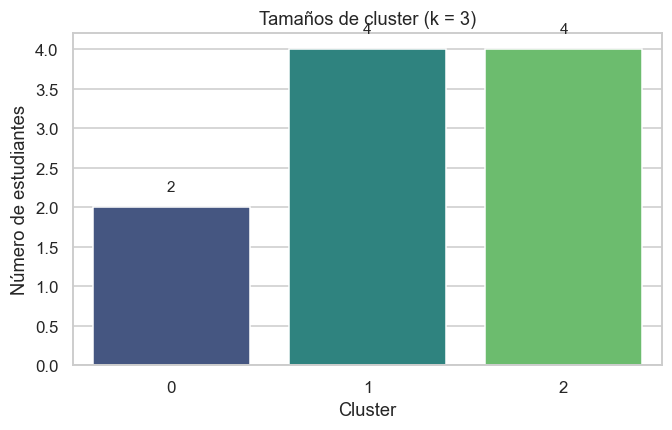

In [8]:
labels = fcluster(Z_ward, K, criterion="maxclust") - 1
sizes = pd.Series(labels).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.8), constrained_layout=True)
gr.plot_tamanos_cluster(sizes, ax, K, ylabel="Número de estudiantes")
plt.show()

## 9. Interpretación: barras y radar

**Barras:** medias por cluster en la escala **estandarizada** (comparas perfiles).  
**Radar:** misma información en forma polar, normalizada 0–100 **dentro de cada variable** para lectura rápida.


/Users/rachitvargaslopez/Documents/LEAD University/Mineria de datos/data_science/data_mining/7 - clustering_jerarquico/scripts/graficos_interpretacion.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


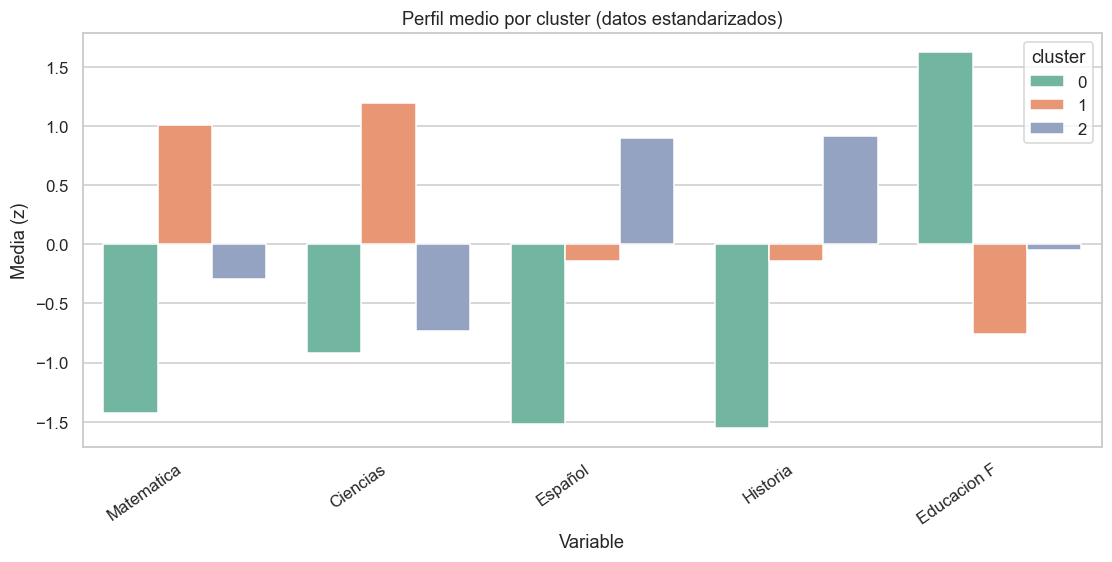

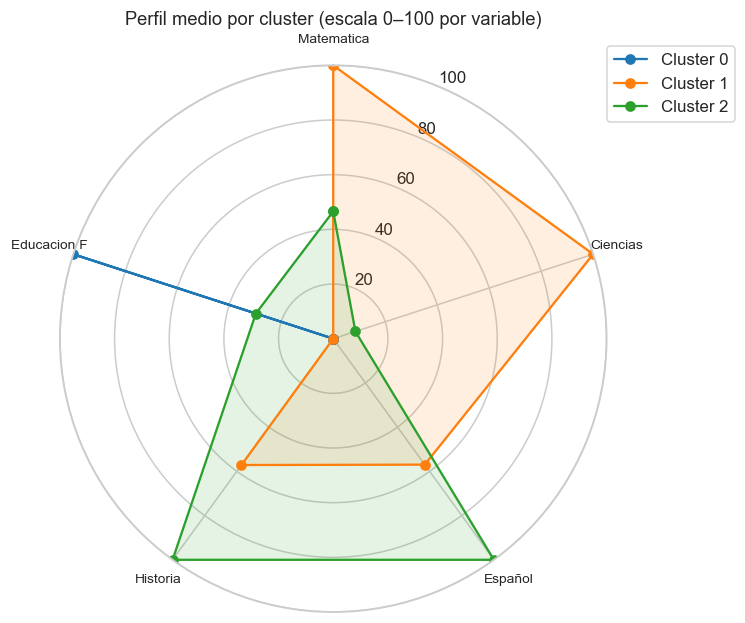

In [9]:
centers = np.array([centroide(c, X_df, labels).values for c in sorted(np.unique(labels))])

long = X_df.copy()
long["cluster"] = labels

melted = long.groupby("cluster", observed=True)[feature_cols].mean().reset_index().melt(
    id_vars="cluster", var_name="Variable", value_name="Media (z)"
)


fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
gr.plot_perfil_barras_z(melted, ax)
plt.show()

fig = gr.plot_radar_centros(centers, feature_cols)
plt.show()

## 10. Mapa de calor de medias por cluster


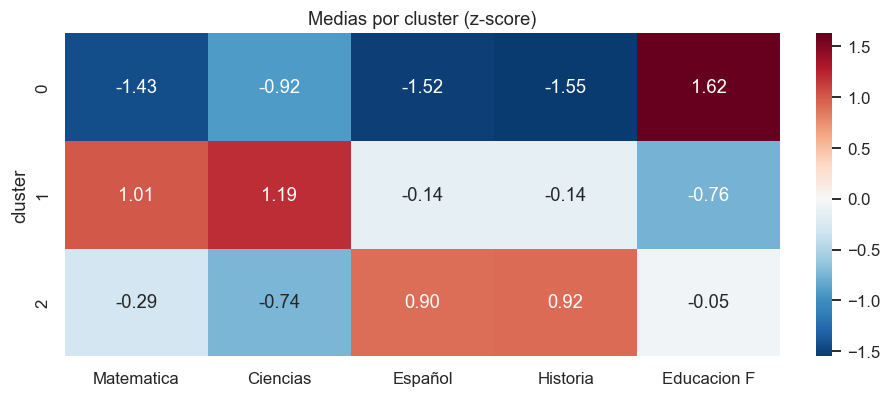

In [10]:
pivot = long.groupby("cluster", observed=True)[feature_cols].mean()
fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
gr.plot_mapa_calor_medias(pivot, ax)
plt.show()

## 11. PCA en 2D

Proyección lineal que resume la variabilidad; los puntos se colorean por cluster para ver si los grupos se separan en el plano principal.


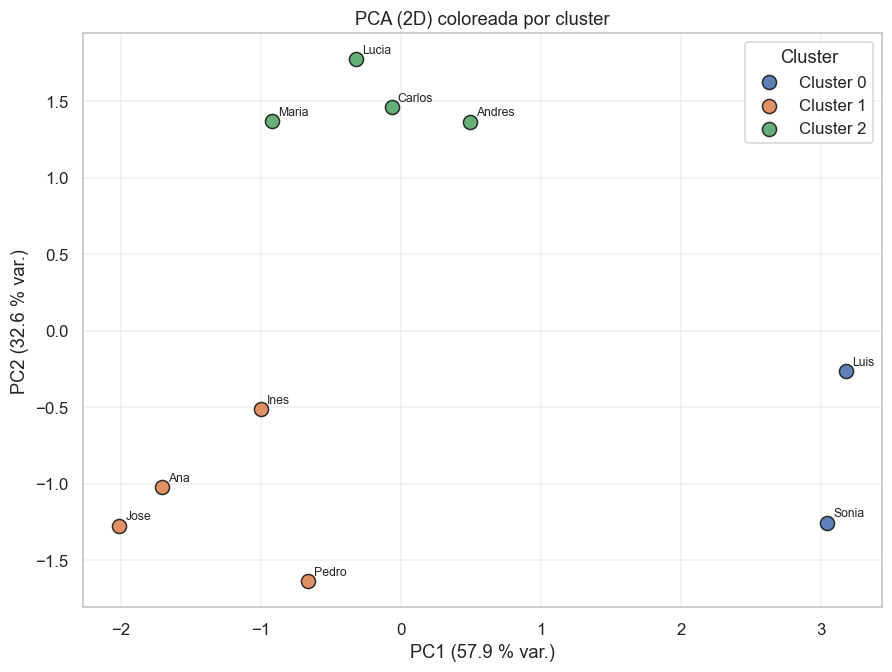

In [11]:
fig, _pca = gr.plot_pca_2d(X, names, labels)
plt.show()



## Figuras adicionales de interpretación

Corte del árbol Ward, correlaciones entre variables, distribuciones por cluster y proyecciones PC1–PC3 (definidos en `scripts/graficos_interpretacion.py`).


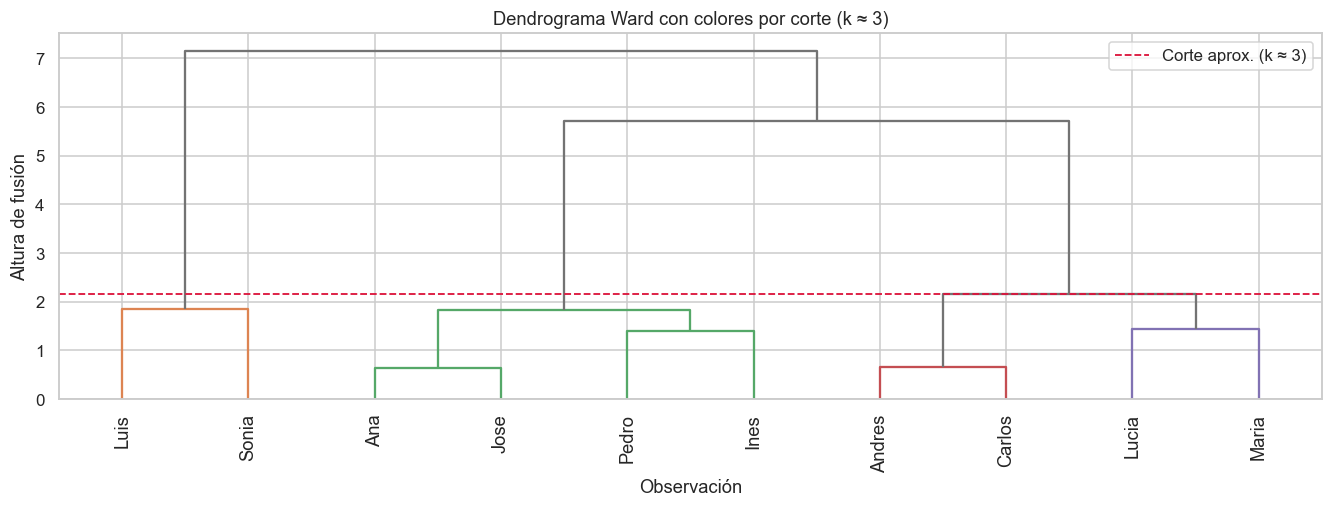

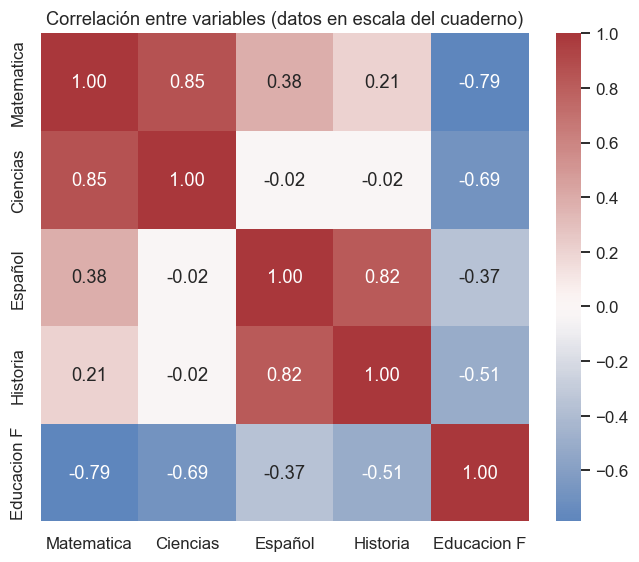

/Users/rachitvargaslopez/Documents/LEAD University/Mineria de datos/data_science/data_mining/7 - clustering_jerarquico/scripts/graficos_interpretacion.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted[melted["variable"] == var], x="cluster", y="valor", ax=ax, palette="pastel")
/Users/rachitvargaslopez/Documents/LEAD University/Mineria de datos/data_science/data_mining/7 - clustering_jerarquico/scripts/graficos_interpretacion.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted[melted["variable"] == var], x="cluster", y="valor", ax=ax, palette="pastel")
/Users/rachitvargaslopez/Documents/LEAD University/Mineria de datos/data_science/data_mining/7 - clustering_je

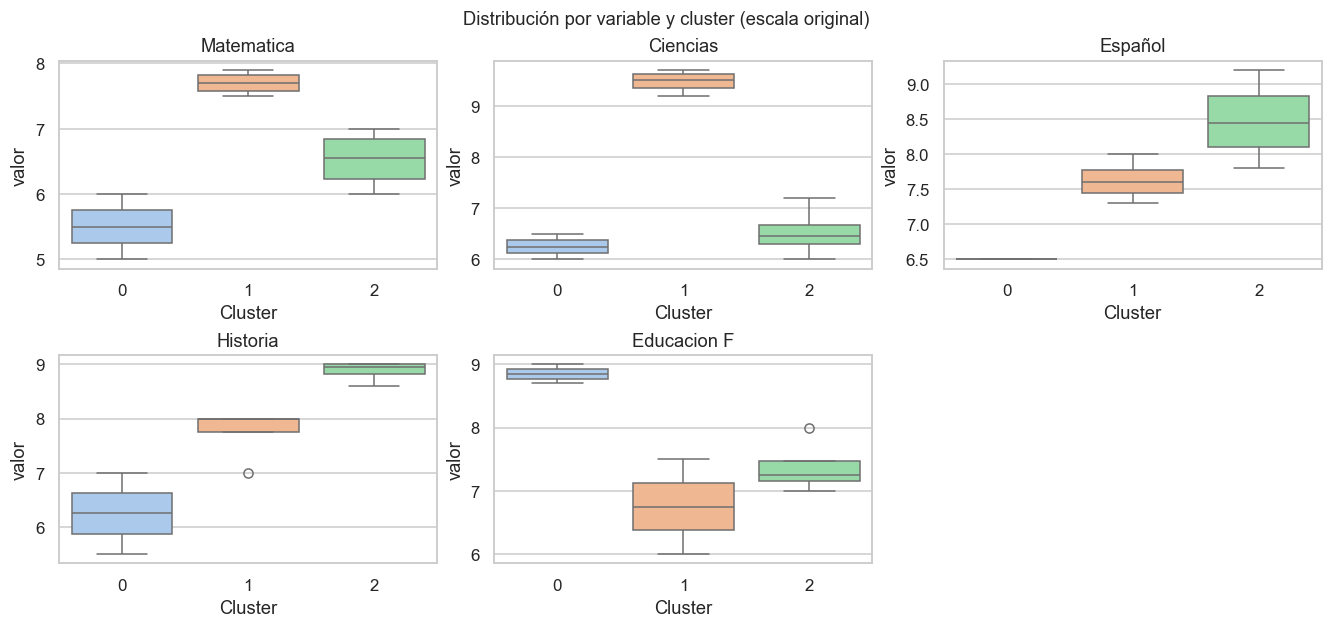

/Users/rachitvargaslopez/Documents/LEAD University/Mineria de datos/data_science/data_mining/7 - clustering_jerarquico/scripts/graficos_interpretacion.py:244: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


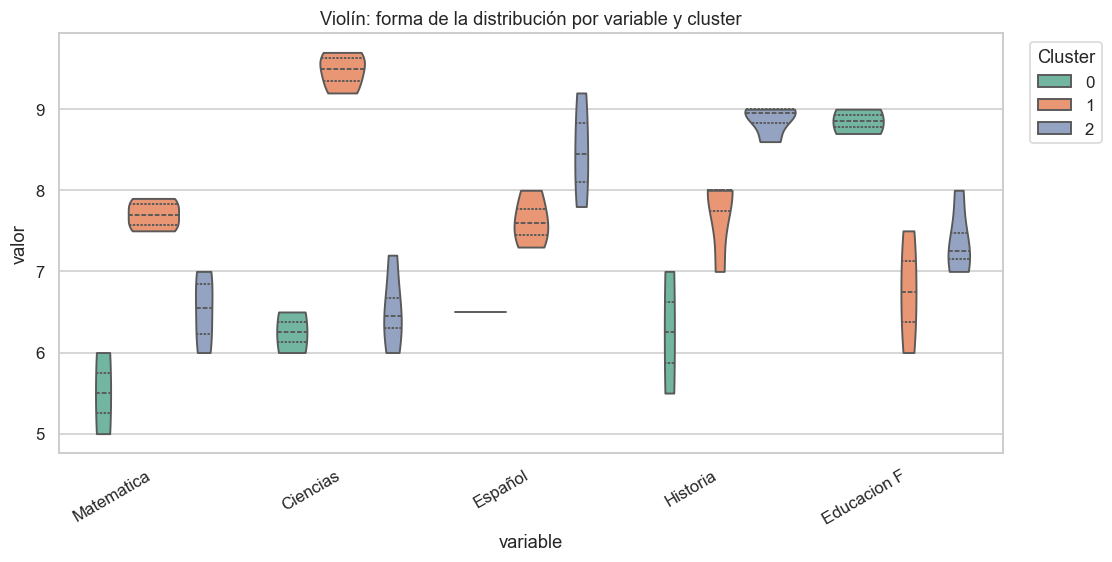

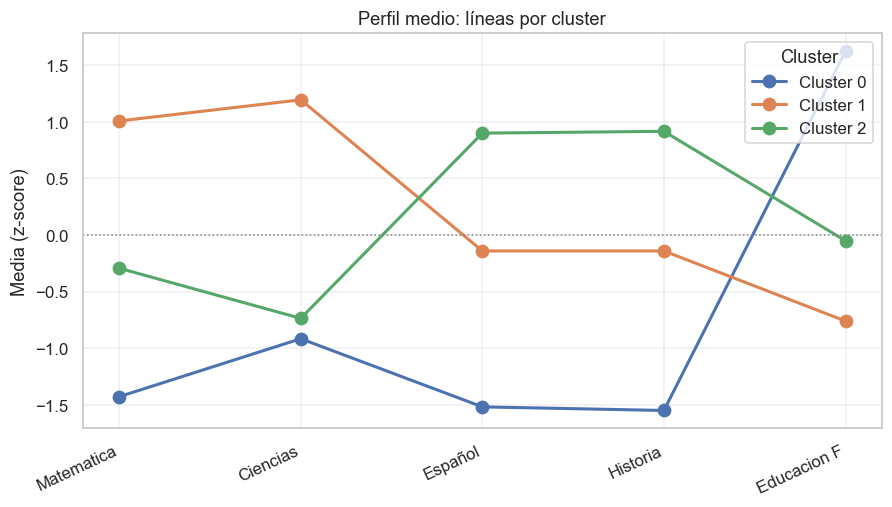

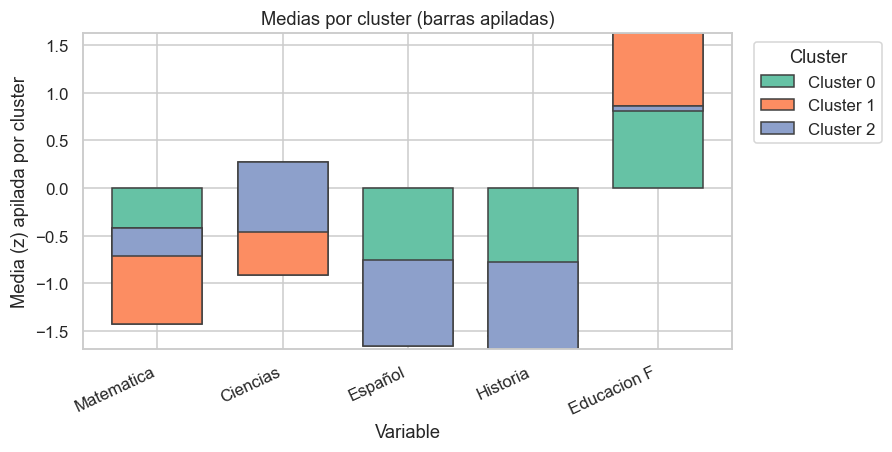

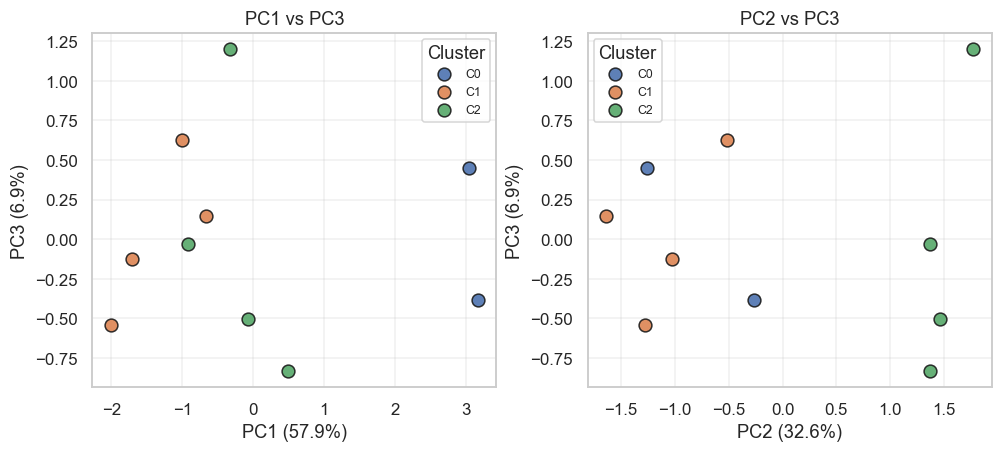

In [12]:
fig = gr.plot_dendrograma_ward_corte(Z_ward, names, K)
plt.show()

fig = gr.plot_correlacion_variables(df[feature_cols], feature_cols)
plt.show()

fig = gr.plot_boxplots_por_cluster(df[feature_cols], labels, feature_cols)
plt.show()

fig = gr.plot_violin_por_variable(df[feature_cols], labels, feature_cols)
plt.show()

fig = gr.plot_perfil_lineas(pivot)
plt.show()

fig = gr.plot_barras_apiladas_medias(pivot)
plt.show()

fig = gr.plot_pair_pca_extra(X, labels)
plt.show()


## 12. Silueta por observación

Cada barra horizontal es un estudiante: **anchos grandes y positivos** indican buena asignación respecto al cluster vecino.


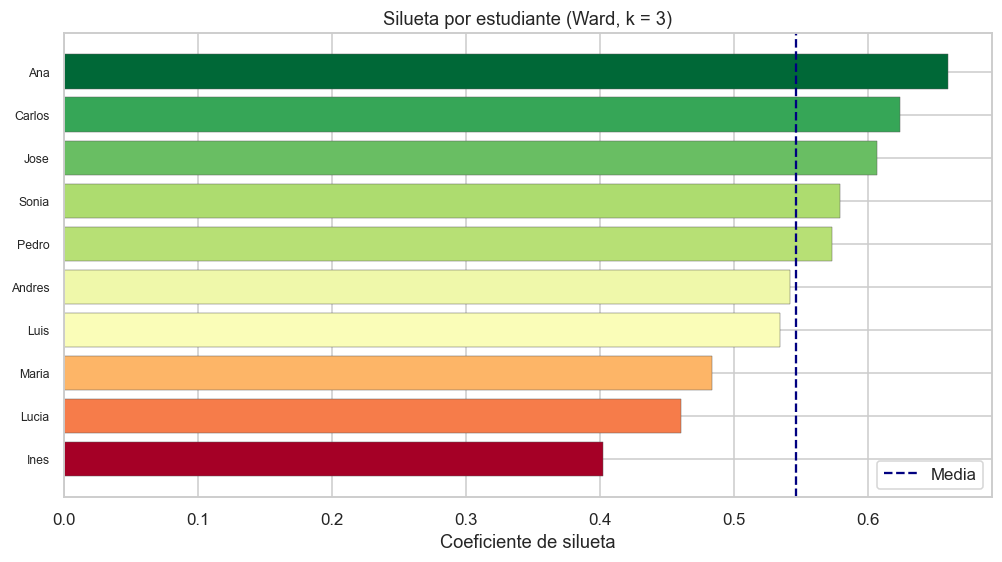

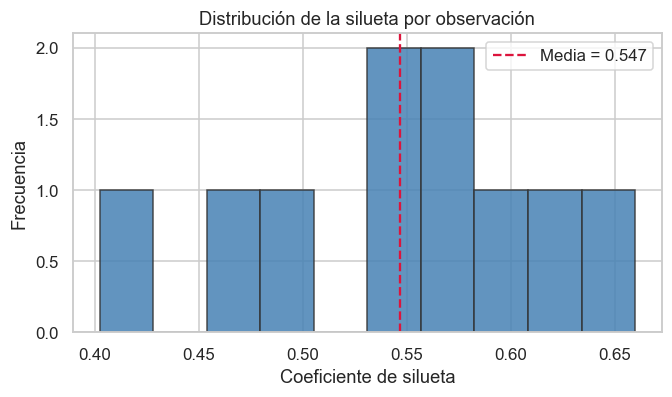

Silueta media: 0.547


In [13]:
sil_vals = silhouette_samples(X, labels, metric="euclidean")
fig = gr.plot_silueta_por_observacion(sil_vals, names, X, labels, K=K, titulo_obs="estudiante")
plt.show()

fig = gr.plot_hist_silueta(sil_vals)
plt.show()
print(f"Silueta media: {sil_vals.mean():.3f}")

## 13. Tabla resumen


In [14]:
out = df[feature_cols].reset_index()
name_col = out.columns[0]
out["cluster"] = labels
display(out.sort_values(["cluster", name_col]))

,Nombre,Matematica,Ciencias,Español,Historia,Educacion F,cluster
3,Luis,5.0,6.5,6.5,7.0,9.0,0
8,Sonia,6.0,6.0,6.5,5.5,8.7,0
5,Ana,7.8,9.6,7.7,8.0,6.5,1
2,Ines,7.6,9.2,8.0,8.0,7.5,1
7,Jose,7.9,9.7,7.5,8.0,6.0,1
1,Pedro,7.5,9.4,7.3,7.0,7.0,1
4,Andres,6.0,6.0,7.8,8.9,7.3,2
6,Carlos,6.3,6.4,8.2,9.0,7.2,2
0,Lucia,7.0,6.5,9.2,8.6,8.0,2
9,Maria,6.8,7.2,8.7,9.0,7.0,2
